# Task 6 - Music Genre Classification

Classifying songs into 10 genres using audio features (tabular approach).
Dataset: GTZAN Dataset - Music Genre Classification from Kaggle (Andrada Olteanu), file features_30_sec.csv: 1,000 songs of 30 seconds, 100 per genre.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading the data
Each row is one song. The audio was already turned into 57 features such as MFCCs, spectral centroid, tempo and zero crossing rate (mean and variance over the 30 seconds).

In [2]:
df = pd.read_csv("features_30_sec.csv")
print(df.shape)
df.head()

(1000, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [3]:
df["label"].value_counts()

,count
label,
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,100
metal,100
pop,100
reggae,100


## 2. Checking the data

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Genres:", sorted(df["label"].unique()))

Missing values: 0
Duplicate rows: 0
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 3. Preparing the data
I removed filename (it contains the genre name) and length (almost the same for every song). The genre names were encoded as numbers 0-9. The features have very different ranges, so I scaled them for SVM and KNN. The scaler is fitted on the training data only.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df.drop(columns=["filename", "length", "label"])

encoder = LabelEncoder()
y = encoder.fit_transform(df["label"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features:", X.shape[1])
print("Train:", len(X_train), "| Test:", len(X_test))
print("Genre codes:", dict(zip(encoder.classes_, range(10))))

Features: 57
Train: 800 | Test: 200
Genre codes: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


## 4. Model comparison
Random Forest uses the unscaled data because trees do not need scaling. SVM and KNN use the scaled data.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Random Forest": (RandomForestClassifier(n_estimators=300, random_state=42), X_train, X_test),
    "SVM": (SVC(kernel="rbf", C=10, random_state=42), X_train_scaled, X_test_scaled),
    "KNN": (KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled),
}

predictions = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    predictions[name] = pred
    print(f"{name}: accuracy {accuracy_score(y_test, pred):.3f} | macro F1 {f1_score(y_test, pred, average='macro'):.3f}")

Random Forest: accuracy 0.710 | macro F1 0.702
SVM: accuracy 0.765 | macro F1 0.764
KNN: accuracy 0.670 | macro F1 0.669


## 5. Results per genre and confusion matrix (SVM)

              precision    recall  f1-score   support

       blues      0.773     0.850     0.810        20
   classical      0.739     0.850     0.791        20
     country      0.850     0.850     0.850        20
       disco      0.688     0.550     0.611        20
      hiphop      0.842     0.800     0.821        20
        jazz      0.773     0.850     0.810        20
       metal      0.941     0.800     0.865        20
         pop      0.737     0.700     0.718        20
      reggae      0.625     0.750     0.682        20
        rock      0.722     0.650     0.684        20

    accuracy                          0.765       200
   macro avg      0.769     0.765     0.764       200
weighted avg      0.769     0.765     0.764       200



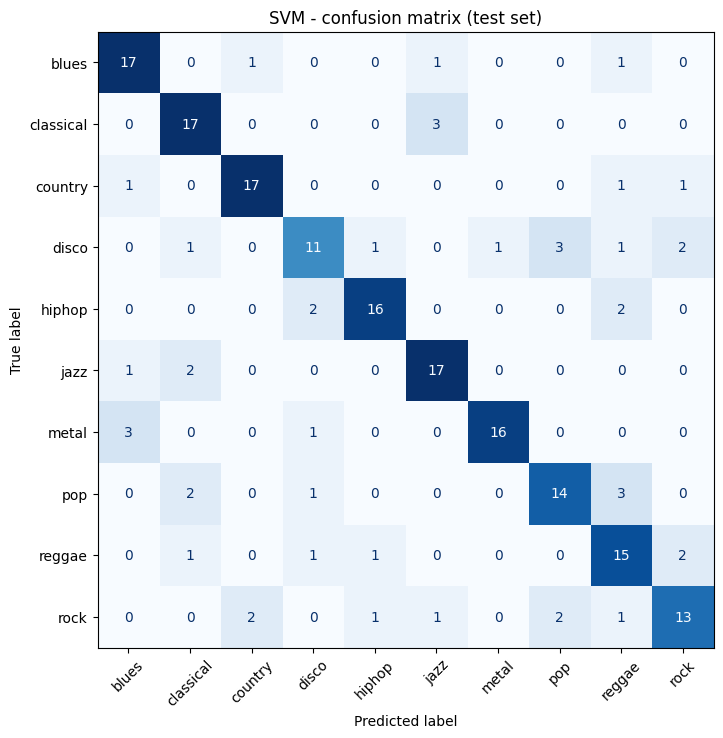

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_pred = predictions["SVM"]

print(classification_report(y_test, best_pred, target_names=encoder.classes_, digits=3))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=encoder.classes_,
                                        cmap="Blues", colorbar=False, ax=ax, xticks_rotation=45)
plt.title("SVM - confusion matrix (test set)")
plt.show()

## Conclusion

I used the tabular approach: 57 audio features (including 20 MFCCs) for 1,000 songs from
10 genres. The classes are perfectly balanced with 100 songs each, and there were no
missing values or duplicates.

Results on the test set (200 songs):
- SVM: accuracy 76.5%, macro F1 0.764
- Random Forest: accuracy 71.0%, macro F1 0.702
- KNN: accuracy 67.0%, macro F1 0.669

SVM was the best model. Random guessing would only get 10%, so all models learned a lot
from the audio features.

Metal (F1 0.865) and country (F1 0.850) were the easiest genres. Disco was the hardest
(F1 0.611), because it was often predicted as other genres with a similar beat.
Most mistakes were between genres that really sound similar, for example metal and blues,
pop and reggae, and rock, which was confused with many different genres.

A CNN on spectrogram images could be tried in the future to compare with this approach.